# Multiple Instance Learning on CAMELYON16
### Mark Sterkel, David Rath

In this notebook, we implement and compare three multiple instance learning (MIL) aggregation strategies on the CAMELYON16 dataset, which consists of lymph node histopathology whole-slide images (WSIs). Each WSI is treated as a bag of instances, from which each 512-pixel tissue patch is an instance. The task is to classify each entire slide as cancerous or normal using only bag-level labels.

We train the models on the precomputed features from the [torchmil CAMELYON16 dataset](https://torchmil.readthedocs.io/en/latest/api/datasets/camelyon16mil_dataset/). Interestingly, the max pooling aggregator beats the more complex attention-based MIL model (ABMIL), and achieves a near-perfect test AUC of 0.9921.

| **Aggregator** | **Test AUC** |
|----------------|:------------:|
| Mean pooling   |    0.8140    |
| Max pooling    |  **0.9921**  |
| ABMIL (gated attention) |   0.9668    |

1. CAMELYON16 Dataset
2. Model
3. Training
4. Analysis & Visualisation

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torchmil.datasets import CAMELYON16MILDataset
from torchmil.datasets.processed_mil_dataset import ProcessedMILDataset
from tensordict import TensorDict as _TensorDict
import tarfile
from huggingface_hub import snapshot_download

In [2]:
def _read_only_cache_getitem(self, index):
    """This is a fix to prevent OOM issues.
    When iterating over a large dataset, the default torchmil __getitem__ permanently caches every loaded bag in RAM.
    Here we use a custom __getitem__ that only caches the currently accessed bag, and discards the previous one
    """
    bag_name = self.bag_names[index]
    bag_dict = self.loaded_bags[bag_name] if bag_name in self.loaded_bags else self._build_bag(bag_name)
    return _TensorDict({k: bag_dict[k] for k in self.bag_keys if k in bag_dict})

ProcessedMILDataset.__getitem__ = _read_only_cache_getitem

In [3]:
# prepare some paths
PROJECT_ROOT = '.'

DATA_DIR    = f'{PROJECT_ROOT}/data/camelyon16'
DATASET_DIR = f'{DATA_DIR}/dataset'
FEATURES_DIR = f"{DATASET_DIR}/patches_512/features/features_resnet50_bt"
CKPT_DIR    = f'{PROJECT_ROOT}/checkpoints'

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

In [4]:
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


Check if the dataset exists, and if not download it. Note, this will download around ~63 GB of data!

In [5]:
if os.path.isdir(FEATURES_DIR) and os.listdir(FEATURES_DIR):
    print("Dataset exists")
else:
    # download all archives to DATA_DIR
    # resumes automatically if interrupted
    snapshot_download(
        repo_id="torchmil/Camelyon16_MIL",
        repo_type="dataset",
        local_dir=DATA_DIR,
    )

    # extract all .tar.gz files
    _patches = f"{DATASET_DIR}/patches_512"
    _to_extract = [
        (f"{_patches}/coords.tar.gz",                         f"{_patches}/coords"),
        (f"{_patches}/labels.tar.gz",                         f"{_patches}/labels"),
        (f"{_patches}/patch_labels.tar.gz",                   f"{_patches}/patch_labels"),
        (f"{_patches}/features/features_resnet50_bt.tar.gz",  FEATURES_DIR),
    ]
    for src, dest in _to_extract:
        if os.path.isdir(dest) and os.listdir(dest):
            print(f"Already extracted: {os.path.basename(src)}")
            continue
        os.makedirs(dest, exist_ok=True)
        print(f"Extracting {os.path.basename(src)} ...", end=" ", flush=True)
        with tarfile.open(src) as t:
            t.extractall(dest, filter="data")
        print("done")

Dataset exists


In [6]:
features_path = os.path.join(DATASET_DIR, 'patches_512', 'features', 'features_resnet50_bt')
print(f"Features extracted: {os.path.isdir(features_path)}")
if os.path.isdir(features_path):
    npy_files = [f for f in os.listdir(features_path) if f.endswith('.npy')]
    print(f"{len(npy_files)} slide files")

Features extracted: True
399 slide files


## CAMELYON16 Dataset
CAMELYON16 consists of 270 training and 129 test H&E-stained whole-slide images of sentinel lymph node tissue from breast cancer patients. Each slide is labelled positive if metastasis is present or negative if not. We use [precomputed embeddings from the torchmil API](https://torchmil.readthedocs.io/en/latest/api/datasets/camelyon16mil_dataset/).

In [7]:
FEATURES     = 'resnet50_bt'
VAL_FRACTION = 0.2
LOAD_AT_INIT = False

full_train_ds = CAMELYON16MILDataset(
    root=DATASET_DIR,
    features=FEATURES,
    partition='train',
    bag_keys=['X', 'Y', 'y_inst', 'coords'],
    load_at_init=LOAD_AT_INIT,
)
test_ds = CAMELYON16MILDataset(
    root=DATASET_DIR,
    features=FEATURES,
    partition='test',
    bag_keys=['X', 'Y', 'y_inst', 'coords'],
    load_at_init=LOAD_AT_INIT,
)

FEAT_DIM = full_train_ds[0]['X'].shape[1]
print(f"Feature dimension: {FEAT_DIM}, Train slides: {len(full_train_ds)}, Test slides: {len(test_ds)}")

train_labels_all = np.array([arr.item() for arr in full_train_ds.get_bag_labels()])
test_labels_arr  = np.array([arr.item() for arr in test_ds.get_bag_labels()])

train_indices, val_indices = train_test_split(
    np.arange(len(full_train_ds)),
    test_size=VAL_FRACTION,
    stratify=train_labels_all,
    random_state=SEED,
)

val_ds = Subset(full_train_ds, val_indices)

train_labels = train_labels_all[train_indices]
val_labels   = train_labels_all[val_indices]

Feature dimension: 2048, Train slides: 270, Test slides: 129


In [8]:
# pre-load all val slides into the cache (train and test slides are never cached)
for i in tqdm(val_indices, desc='pre-caching val slides', leave=False):
    name = full_train_ds.bag_names[i]
    if name not in full_train_ds.loaded_bags:
        full_train_ds.loaded_bags[name] = full_train_ds._build_bag(name)

for split, labels in [("Train pool", train_labels), ("Val  ", val_labels), ("Test ", test_labels_arr)]:
    pos = labels.sum()
    print(f"{split}: {len(labels)} slides  ({pos} positive, {len(labels)-pos} negative)")

pre-caching val slides:   0%|          | 0/54 [00:00<?, ?it/s]

Train pool: 216 slides  (89 positive, 127 negative)
Val  : 54 slides  (22 positive, 32 negative)
Test : 129 slides  (49 positive, 80 negative)


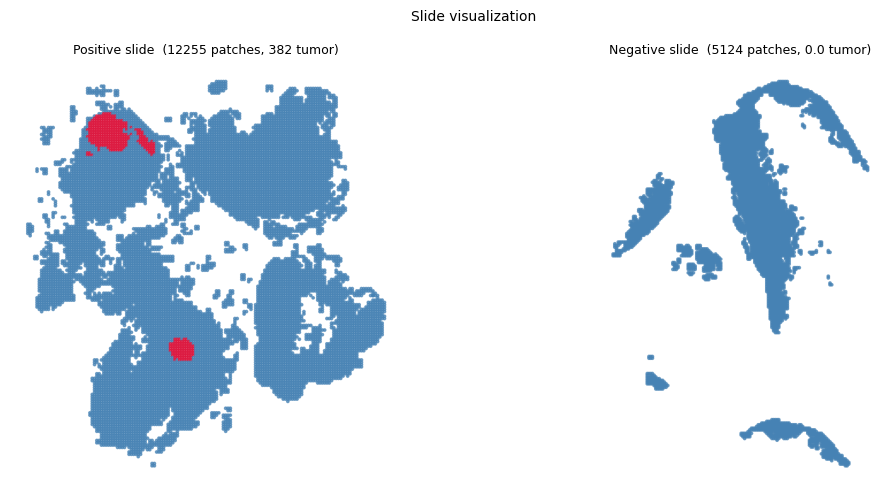

In [9]:
# show a positive and a negative example
pos_slide_idx = [i for i, lbl in enumerate(test_labels_arr) if lbl == 1]
neg_slide_idx = [i for i, lbl in enumerate(test_labels_arr) if lbl == 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, slide_idx, split_label in zip(axes, [pos_slide_idx[0], neg_slide_idx[0]], ['Positive', 'Negative']):
    item   = test_ds[slide_idx]
    coords = item['coords'].numpy()    # (N, 2)
    y_inst = item['y_inst'].numpy()    # (N,)
    colors = np.where(y_inst, 'crimson', 'steelblue')
    ax.scatter(coords[:, 0], -coords[:, 1], c=colors, s=3, alpha=0.7)
    ax.set_title(
        f"{split_label} slide  ({len(y_inst)} patches, {y_inst.sum()} tumor)",
        fontsize=9
    )
    ax.set_aspect('equal')
    ax.axis('off')
plt.suptitle("Slide visualization", fontsize=10)
plt.tight_layout()
plt.show()

### Dataset Statistics

Next, we look at some statistics of the dataset: bag size distribution, class distribution and tumor patch distribution.

In [ ]:
_coord_path       = os.path.join(DATASET_DIR, 'patches_512', 'coords')
_label_path       = os.path.join(DATASET_DIR, 'patches_512', 'labels')
_patch_label_path = os.path.join(DATASET_DIR, 'patches_512', 'patch_labels')

# read coord files (2 KB) instead of feature files (60 MB)
train_bag_sizes = [
    np.load(os.path.join(_coord_path, n + '.npy')).shape[0]
    for n in tqdm(full_train_ds.get_bag_names(), desc='train bag sizes', leave=False)
]
test_bag_sizes = [
    np.load(os.path.join(_coord_path, n + '.npy')).shape[0]
    for n in tqdm(test_ds.get_bag_names(), desc='test bag sizes', leave=False)
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.hist(train_bag_sizes, bins=30, alpha=0.6, label='Train', edgecolor='white', linewidth=0.4)
ax.hist(test_bag_sizes,  bins=30, alpha=0.6, label='Test',  edgecolor='white', linewidth=0.4)
ax.set_xlabel("Patches per slide")
ax.set_ylabel("Count")
ax.set_title("Bag size distribution")
ax.legend()

ax = axes[1]
splits_bar = [("Train", train_labels), ("Val", val_labels), ("Test", test_labels_arr)]
x = np.arange(len(splits_bar))
w = 0.35
pos_c = [lbl.sum() for _, lbl in splits_bar]
neg_c = [len(lbl) - p for (_, lbl), p in zip(splits_bar, pos_c)]
ax.bar(x - w/2, pos_c, w, label="Positive", color="steelblue")
ax.bar(x + w/2, neg_c, w, label="Negative", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels([s for s, _ in splits_bar])
ax.set_ylabel("Slides")
ax.set_title("Positive / negative slides per split")
ax.legend()

ax = axes[2]
tumor_fracs = []
for name in tqdm(test_ds.get_bag_names(), desc='tumor fracs', leave=False):
    lbl = np.load(os.path.join(_label_path, name + '.npy')).item()
    if lbl == 1:
        pl = np.load(os.path.join(_patch_label_path, name + '.npy'))
        tumor_fracs.append(pl.mean())
ax.hist(tumor_fracs, bins=20, edgecolor='black', color='steelblue')
ax.set_xlabel("Fraction of tumor patches")
ax.set_ylabel("Count")
ax.set_title("Tumor patch fraction\n(positive test slides)")

plt.tight_layout()
plt.show()

print(f"Patches per slide: mean={np.mean(train_bag_sizes):.0f}  "
      f"min={min(train_bag_sizes)}  max={max(train_bag_sizes)}")

train bag sizes:   0%|          | 0/270 [00:00<?, ?it/s]

test bag sizes:   0%|          | 0/129 [00:00<?, ?it/s]

## Model
Compared to the original ABMIL implementation, we use a different architecture. Since we train on precomputed features, the CNN encoder is replaced by a two-layer projector (fc-512, ReLU, Dropout(0.25), fc-512, ReLU, Dropout(0.25)) that processes the 2048-dim patch embeddings before aggregation. We again compare three aggregators: mean, max, and attention.

In [ ]:
class FeatureProjector(nn.Module):
    """Two fc-512 layers with dropout before MIL pooling (Ilse et al., Table 15).

    Since input features are precomputed ResNet-50 Barlow Twins embeddings rather
    than raw pixels, we remove the CNN layers. The two fc layers serve as the
    embedding refinement step to try to match the paper's histopathology architecture.

    Args:
        in_dim:  Input feature dimension (FEAT_DIM, e.g. 2048 for resnet50_bt).
        out_dim: Output dimension passed to the aggregator.
        dropout: Dropout probability applied after each fc layer.

    Input:  (N, in_dim)
    Output: (N, out_dim)
    """

    def __init__(self, in_dim: int, out_dim: int = 512, dropout: float = 0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(out_dim, out_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):    # (N, in_dim)
        return self.net(x)   # (N, out_dim)


class MeanPoolAggregator(nn.Module):
    """Element-wise mean over instance features."""

    def forward(self, h):
        return h.mean(dim=0, keepdim=True), None


class MaxPoolAggregator(nn.Module):
    """Element-wise max over instance features."""

    def forward(self, h):
        return h.max(dim=0, keepdim=True).values, None


class AttentionAggregator(nn.Module):
    """Gated attention aggregator (Ilse et al., ICML 2018).

    Attention score per instance:
        a_i = softmax( w^T ( tanh(V h_i) o sigmoid(U h_i) ) )

    Bag representation:
        z = sum_i a_i h_i

    Args:
        L: Input feature dimension (must match projector output).
        D: Internal attention dimension.
    """

    def __init__(self, L: int = 500, D: int = 128):
        super().__init__()
        self.V = nn.Linear(L, D)
        self.U = nn.Linear(L, D)
        self.w = nn.Linear(D, 1)

    def forward(self, h):                                               # (N, L)
        a = self.w(torch.tanh(self.V(h)) * torch.sigmoid(self.U(h)))  # (N, 1)
        a = torch.softmax(a, dim=0)                                    # (N, 1)
        z = (a * h).sum(dim=0, keepdim=True)                           # (1, L)
        return z, a.squeeze(1)                                         # (1, L), (N,)


class MILModel(nn.Module):
    """Feature projector + aggregator + binary bag classifier.

    Always returns (logit, attention_weights), where attention_weights is None
    for non-adaptive aggregators.

    Args:
        projector:   FeatureProjector instance.
        aggregator:  One of MeanPoolAggregator, MaxPoolAggregator, AttentionAggregator.
        hidden_dim:  Projector output / aggregator input dimension.
    """

    def __init__(self, projector: nn.Module, aggregator: nn.Module, hidden_dim: int = 500):
        super().__init__()
        self.projector  = projector
        self.aggregator = aggregator
        self.classifier = nn.Linear(hidden_dim, 1)

    def forward(self, X):                           # (N, feat_dim)
        h          = self.projector(X)              # (N, hidden_dim)
        z, weights = self.aggregator(h)             # (1, hidden_dim), (N,) or None
        logit      = self.classifier(z).squeeze()   # scalar
        return logit, weights

In [ ]:
# test the forward pass of the models with some dummy data
HIDDEN_DIM = 512
ATTN_DIM   = 128
DROPOUT    = 0.25

_X = torch.randn(200, FEAT_DIM)   # 200 patches, realistic bag
for name, agg in [("mean", MeanPoolAggregator()),
                  ("max",  MaxPoolAggregator()),
                  ("attn", AttentionAggregator(HIDDEN_DIM, ATTN_DIM))]:
    model = MILModel(FeatureProjector(FEAT_DIM, HIDDEN_DIM, DROPOUT), agg, HIDDEN_DIM)
    logit, w = model(_X)
    w_shape  = tuple(w.shape) if w is not None else None
    print(f"{name:4s}  logit={tuple(logit.shape)}  weights={w_shape}")

mean  logit=()  weights=None
max   logit=()  weights=None
attn  logit=()  weights=(200,)


## Training

In [ ]:
EPOCHS                  = 100
LR                      = 1e-4
WEIGHT_DECAY            = 5e-4
EARLY_STOPPING_PATIENCE = 10

criterion = nn.BCEWithLogitsLoss()



# prepare the dataset
# we use load_at_init=False to not load the entire dataset into memory at once
_train_ds = CAMELYON16MILDataset(
    root=DATASET_DIR,
    features=FEATURES,
    partition='train',
    bag_keys=['X', 'Y'],
    load_at_init=False,
)


def _collate(batch):
    return batch[0]

train_loader = DataLoader(Subset(_train_ds, train_indices), batch_size=1, shuffle=True,  collate_fn=_collate, num_workers=0)
val_loader   = DataLoader(                          val_ds, batch_size=1, shuffle=False, collate_fn=_collate, num_workers=0)
test_loader  = DataLoader(                         test_ds, batch_size=1, shuffle=False, collate_fn=_collate, num_workers=0)

We use early stopping with a patience of 10 epochs on the validation loss.

In [ ]:
class EarlyStopper:
    def __init__(self, patience=1, min_delta=0):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best      = float('inf')

    def step(self, val_loss):
        if val_loss < (self.best - self.min_delta):
            self.best    = val_loss
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for item in loader:
        X = item['X'].to(device)
        Y = item['Y'].float().squeeze().to(device)
        optimizer.zero_grad()
        logit, _ = model(X)
        loss = criterion(logit, Y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate_full(model, loader, criterion, device):
    """Returns (val_loss, val_auc) in a single pass — avoids iterating the loader twice."""
    model.eval()
    total_loss, probs, labels = 0.0, [], []
    with torch.no_grad():
        for item in loader:
            X = item['X'].to(device)
            Y = item['Y'].float().squeeze().to(device)
            logit, _ = model(X)
            total_loss += criterion(logit, Y).item()
            probs.append(torch.sigmoid(logit).item())
            labels.append(int(Y.item()))
    return total_loss / len(loader), roc_auc_score(labels, probs)


def evaluate(model, loader, device):
    """Returns AUC on the given loader."""
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for item in loader:
            X = item['X'].to(device)
            logit, _ = model(X)
            probs.append(torch.sigmoid(logit).item())
            labels.append(int(item['Y'].item()))
    return roc_auc_score(labels, probs)


def plot_confusion_matrix(model, loader, device, name):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for item in loader:
            X = item['X'].to(device)
            logit, _ = model(X)
            preds.append((torch.sigmoid(logit) > 0.5).int().item())
            labels.append(int(item['Y'].item()))
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14,
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Neg', 'Pos'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Neg', 'Pos'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{name} confusion matrix')
    plt.tight_layout()
    plt.show()

Here we actually train the models (took 1.5 hours on my NVIDIA GeForce GTX 1070 GPU). You can skip this cell if you have the model weights in `checkpoints/`.

mean:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stopping at epoch 58


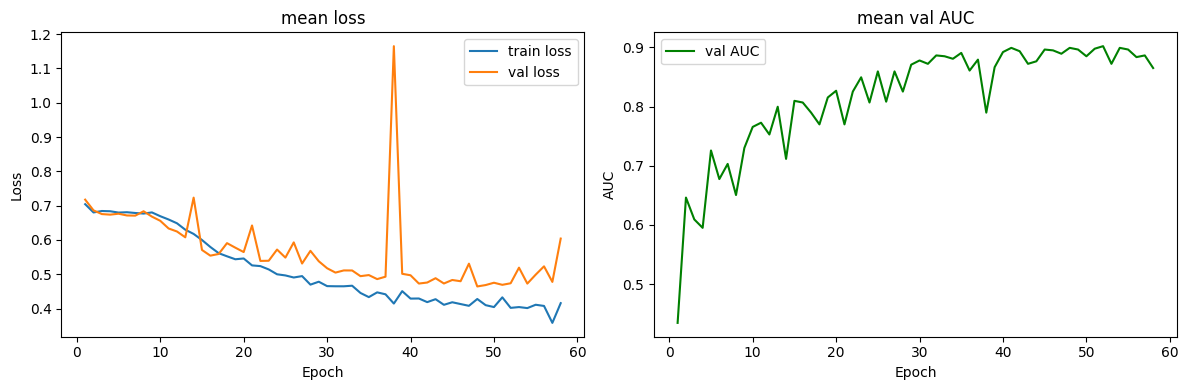

  mean  AUC=0.8140


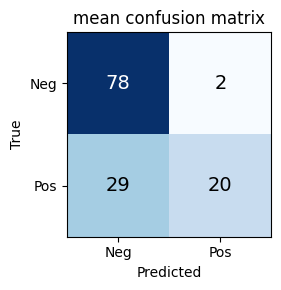

max:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stopping at epoch 38


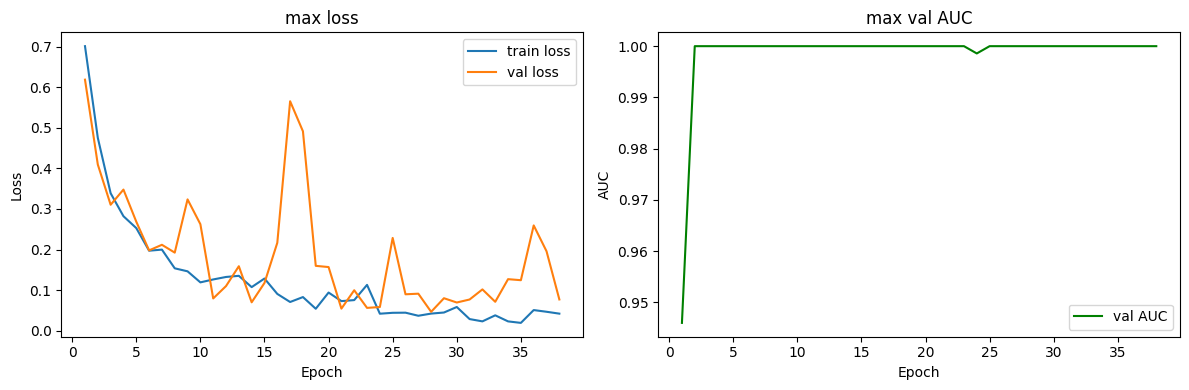

  max   AUC=0.9921


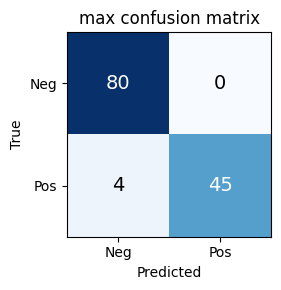

attn:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stopping at epoch 36


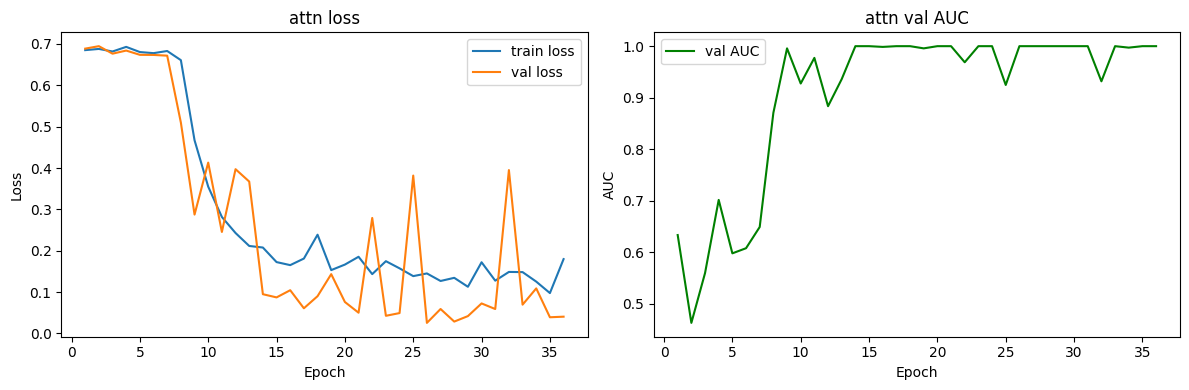

  attn  AUC=0.9668


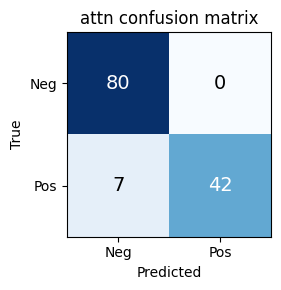

In [ ]:
# train the models
trained_models = {}

configs = [
    ("mean", MeanPoolAggregator()),
    ("max",  MaxPoolAggregator()),
    ("attn", AttentionAggregator(HIDDEN_DIM, ATTN_DIM)),
]

for name, agg in configs:
    model     = MILModel(FeatureProjector(FEAT_DIM, HIDDEN_DIM, DROPOUT), agg, HIDDEN_DIM).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    stopper   = EarlyStopper(patience=EARLY_STOPPING_PATIENCE, min_delta=1e-3)

    train_losses, val_losses, val_aucs = [], [], []
    best_state = None

    pbar = tqdm(range(1, EPOCHS + 1), desc=name)
    for epoch in pbar:
        train_loss        = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_loss, val_auc = evaluate_full(model, val_loader, criterion, DEVICE)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_aucs.append(val_auc)

        if val_loss <= stopper.best:
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        should_stop = stopper.step(val_loss)
        pbar.set_postfix(tr=f'{train_loss:.3f}', val=f'{val_loss:.3f}',
                         auc=f'{val_auc:.3f}', es=f'{stopper.counter}/{stopper.patience}')
        if should_stop:
            print(f"  Early stopping at epoch {epoch}")
            break

    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

    epochs_ran = range(1, len(train_losses) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs_ran, train_losses, label='train loss')
    ax1.plot(epochs_ran, val_losses,   label='val loss')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title(f'{name} loss'); ax1.legend()
    ax2.plot(epochs_ran, val_aucs, color='green', label='val AUC')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('AUC')
    ax2.set_title(f'{name} val AUC'); ax2.legend()
    plt.tight_layout(); plt.show()

    torch.save(model.state_dict(), f"{CKPT_DIR}/camelyon_{name}.pt")
    test_auc = evaluate(model, test_loader, DEVICE)
    print(f"  {name:4s}  AUC={test_auc:.4f}")
    plot_confusion_matrix(model, test_loader, DEVICE, name)
    trained_models[name] = model

In [ ]:
# load the model weights from checkpoints/
trained_models = {}
models = [
    ("mean", MeanPoolAggregator()),
    ("max",  MaxPoolAggregator()),
    ("attn", AttentionAggregator(HIDDEN_DIM, ATTN_DIM))
]

for name, agg in models:

    path = f"{CKPT_DIR}/camelyon_{name}.pt"

    model = MILModel(FeatureProjector(FEAT_DIM, HIDDEN_DIM, DROPOUT), agg, HIDDEN_DIM).to(DEVICE)
    model.load_state_dict(torch.load(path, weights_only=True))
    model.eval()

    trained_models[name] = model

    print(f"Loaded {name} ({path})")

Loaded mean (./checkpoints/camelyon_mean.pt)
Loaded max (./checkpoints/camelyon_max.pt)
Loaded attn (./checkpoints/camelyon_attn.pt)


## Results

Next, we evaluate all three aggregators on the test set and visualize their properties. In particular, we inspect whether ABMIL attention localises actual tumor tissue.

ROC curves:   0%|          | 0/3 [00:00<?, ?it/s]

mean:   0%|          | 0/129 [00:00<?, ?it/s]

  mean    AUC = 0.8140


max:   0%|          | 0/129 [00:00<?, ?it/s]

  max     AUC = 0.9921


attn:   0%|          | 0/129 [00:00<?, ?it/s]

  attn    AUC = 0.9668


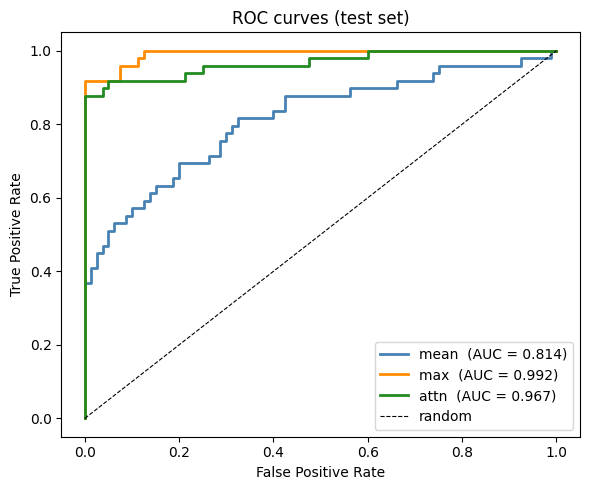

In [ ]:
# set the attention model to eval
attn_model = trained_models["attn"]
attn_model.eval()

fig, ax = plt.subplots(figsize=(6, 5))
colors = {"mean": "steelblue", "max": "darkorange", "attn": "forestgreen"}

for name, model in tqdm(trained_models.items(), desc='ROC curves', position=0, leave=True):
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for item in tqdm(test_loader, desc=name, position=1, leave=False):
            X = item['X'].to(DEVICE)
            logit, _ = model(X)
            probs.append(torch.sigmoid(logit).item())
            labels.append(int(item['Y'].item()))
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    ax.plot(fpr, tpr, label=f"{name}  (AUC = {auc:.3f})", color=colors[name], linewidth=2)
    print(f"  {name:6s}  AUC = {auc:.4f}")

ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves (test set)")
ax.legend()
plt.tight_layout()
plt.show()

### Attention Maps

Here we compare the attention maps generated by the ABMIL model to the actual tumor locations on the slide. A well trained model should assign high attention scores to regions which contain tumors.

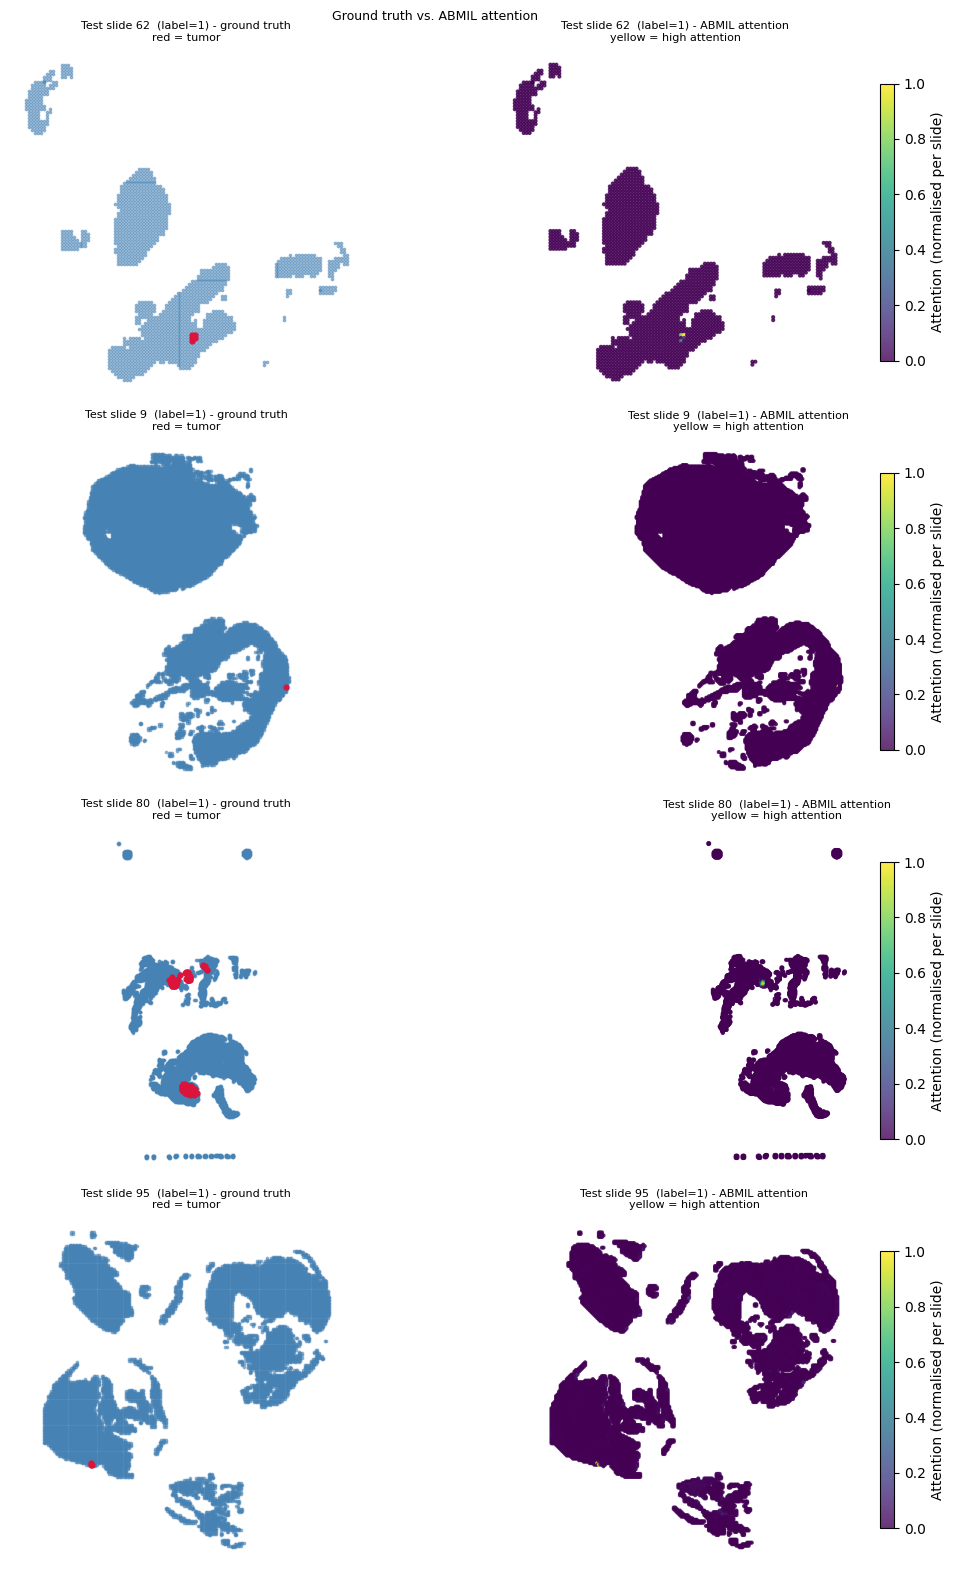

In [ ]:
# prepare the attention maps for four random test slides

# get some random (seeded) positive slides
test_pos_indices = [i for i, lbl in enumerate(test_labels_arr) if lbl == 1]
chosen = np.random.default_rng(SEED).choice(
    test_pos_indices, size=min(4, len(test_pos_indices)), replace=False
)

fig, axes = plt.subplots(len(chosen), 2, figsize=(11, 4 * len(chosen)))
if len(chosen) == 1:
    axes = axes[np.newaxis, :]

for row, idx in enumerate(chosen):
    item   = test_ds[idx]
    X      = item['X'].to(DEVICE)
    coords = item['coords'].numpy()    # (N, 2)
    y_inst = item['y_inst'].numpy()    # (N,)
    label  = int(item['Y'].item())

    with torch.no_grad():
        _, attn_w = attn_model(X)
    attn_w = attn_w.cpu().numpy()

    # normalize scores between 0 and 1
    attn_w_norm = (attn_w - attn_w.min()) / (attn_w.max() - attn_w.min() + 1e-10)

    # ground truth
    ax = axes[row, 0]
    normal_mask = y_inst == 0
    tumor_mask  = y_inst == 1
    ax.scatter(coords[normal_mask, 0], -coords[normal_mask, 1],
               c='steelblue', s=3, alpha=0.5)
    if tumor_mask.any():
        ax.scatter(coords[tumor_mask, 0], -coords[tumor_mask, 1],
                   c='crimson', s=12, alpha=1.0, zorder=5)
        
    n_tumor = int(tumor_mask.sum())
    ax.set_title(f"Test slide {idx}  (label={label}) - ground truth\n"
                 f"red = tumor", fontsize=8)
    ax.set_aspect('equal')
    ax.axis('off')

    # attention map
    ax = axes[row, 1]
    sc = ax.scatter(coords[:, 0], -coords[:, 1], c=attn_w_norm,
                    cmap='viridis', vmin=0, vmax=1, s=4, alpha=0.8)
    plt.colorbar(sc, ax=ax, label="Attention (normalised per slide)", shrink=0.8)
    ax.set_title(f"Test slide {idx}  (label={label}) - ABMIL attention\n"
                 f"yellow = high attention", fontsize=8)
    ax.set_aspect('equal')
    ax.axis('off')

plt.suptitle("Ground truth vs. ABMIL attention", fontsize=9)
plt.tight_layout()
plt.show()

### Attention Weight Distribution

Next, we check the distribution of tumor to non-tumor attention weights. A well trained model should assign higher attention weights to tumor patches than normal patches.

attn distribution:   0%|          | 0/129 [00:00<?, ?it/s]

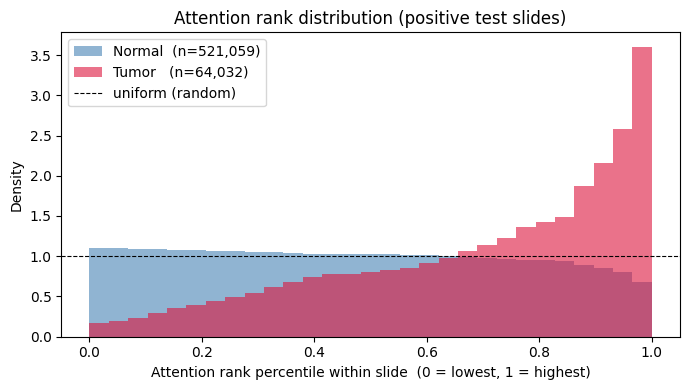

Mean: 0.691  normal: 0.477  (random baseline: 0.500)


In [ ]:
tumor_ranks_all, normal_ranks_all = [], []

attn_model.eval()
with torch.no_grad():
    for item in tqdm(test_loader, desc='attn distribution', leave=False):
        if item['Y'].item() != 1:
            continue
        X      = item['X'].to(DEVICE)
        y_inst = item['y_inst'].numpy()
        _, attn_w = attn_model(X)
        attn_w = attn_w.cpu().numpy()

        n = len(attn_w)
        # Double argsort → 0-indexed rank; divide by (n-1) → [0, 1]
        ranks = np.argsort(np.argsort(attn_w)) / (n - 1)

        tumor_ranks_all.extend(ranks[y_inst == 1].tolist())
        normal_ranks_all.extend(ranks[y_inst == 0].tolist())

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, 1, 30)
ax.hist(normal_ranks_all, bins=bins, alpha=0.6, density=True,
        label=f"Normal  (n={len(normal_ranks_all):,})", color='steelblue')
ax.hist(tumor_ranks_all, bins=bins, alpha=0.6, density=True,
        label=f"Tumor   (n={len(tumor_ranks_all):,})", color='crimson')
ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, label='uniform (random)')
ax.set_xlabel("Attention rank percentile within slide  (0 = lowest, 1 = highest)")
ax.set_ylabel("Density")
ax.set_title("Attention rank distribution (positive test slides)")
ax.legend()
plt.tight_layout()
plt.show()

if tumor_ranks_all and normal_ranks_all:
    print(f"Mean attention rank - tumor: {np.mean(tumor_ranks_all):.3f}  "
          f"normal: {np.mean(normal_ranks_all):.3f}  "
          f"(random baseline: 0.500)")

### t-SNE of Patch Features

Here we generate a t-SNE plot of the patch features. We expect a well trained model to cluster tumor patches away from normal patches in the feature space.

extracting features:   0%|          | 0/129 [00:00<?, ?it/s]

Running t-SNE on 5000 patches...


c:\Users\User\miniconda3\envs\project\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


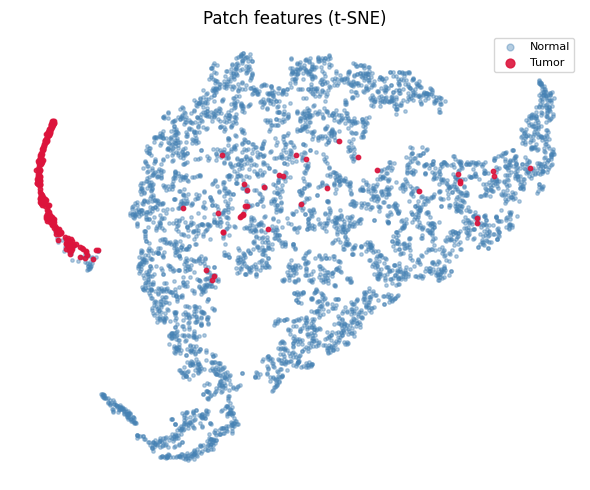

In [ ]:
all_feats, all_y_inst = [], []

attn_model.eval()
with torch.no_grad():
    for item in tqdm(test_loader, desc='extracting features', leave=False):
        X = item['X'].to(DEVICE)
        h = attn_model.projector(X)
        all_feats.append(h.cpu())
        all_y_inst.append(item['y_inst'])

feats  = torch.cat(all_feats).numpy()
y_inst = torch.cat(all_y_inst).numpy().astype(int)

MAX_POINTS = 5000
if len(feats) > MAX_POINTS:
    sub_idx = np.random.default_rng(SEED).choice(len(feats), size=MAX_POINTS, replace=False)
    feats, y_inst = feats[sub_idx], y_inst[sub_idx]

print(f"Running t-SNE on {len(feats)} patches...")
coords_tsne = TSNE(n_components=2, random_state=SEED, perplexity=30).fit_transform(feats)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(coords_tsne[y_inst == 0, 0], coords_tsne[y_inst == 0, 1],
           c='steelblue', s=6, alpha=0.4, label='Normal')
ax.scatter(coords_tsne[y_inst == 1, 0], coords_tsne[y_inst == 1, 1],
           c='crimson', s=10, alpha=0.9, zorder=5, label='Tumor')
ax.set_title("Patch features (t-SNE)")
ax.legend(markerscale=2, fontsize=8)
ax.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
per_slide_aucs = []

attn_model.eval()
with torch.no_grad():
    for item in tqdm(test_loader, desc='per-slide instance AUC', leave=False):
        if item['Y'].item() != 1:
            continue
        X = item['X'].to(DEVICE)
        _, attn_w = attn_model(X)
        y_inst = item['y_inst'].numpy().astype(int)
        w = attn_w.cpu().numpy()
        # skip degenerate slides where AUC is undefined
        if y_inst.sum() == 0 or y_inst.sum() == len(y_inst):
            continue
        per_slide_aucs.append(roc_auc_score(y_inst, w))

print(f"Per-slide instance AUC: {np.mean(per_slide_aucs):.4f} ± {np.std(per_slide_aucs):.4f}")
print(f"  across {len(per_slide_aucs)} positive test slides")

### Misclassified Slides

Finally, we look at some misclassified slides to see if we can identify any patterns in the errors. The model made no false positives, but some false negatives. In the case of some false negatives, it seems that the model has predicted some patches with high attention, but that this was not enough to trigger a positive prediction.

misclassifications:   0%|          | 0/129 [00:00<?, ?it/s]

False positives: 0  (predicted positive, label negative)
False negatives: 7  (predicted negative, label positive)
No false positives on test set.

False negatives


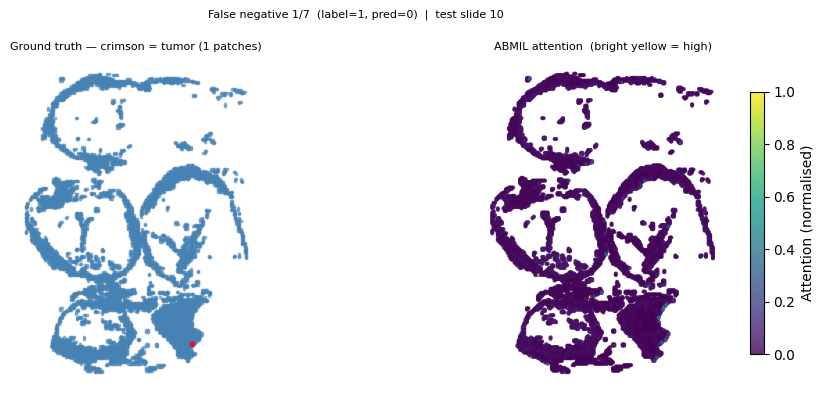

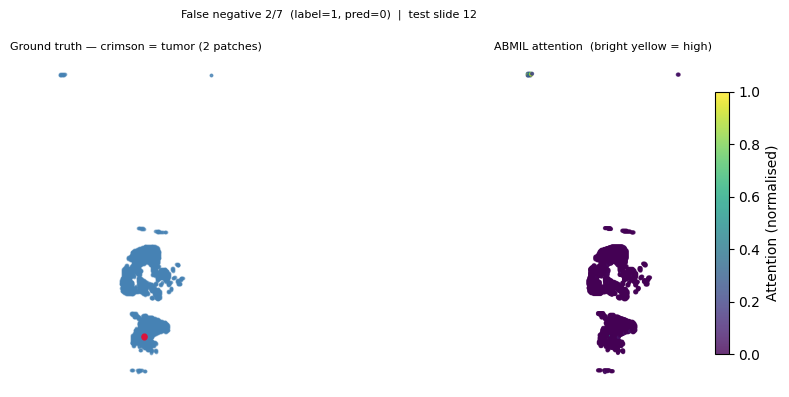

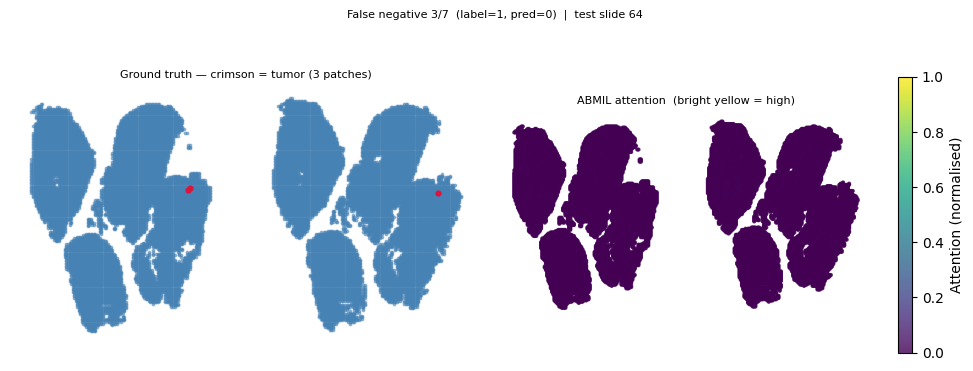

In [23]:
attn_model.eval()
fp_items, fn_items = [], []

with torch.no_grad():
    for i, item in enumerate(tqdm(test_loader, desc='misclassifications', leave=False)):
        X     = item['X'].to(DEVICE)
        label = int(item['Y'].item())
        logit, attn_w = attn_model(X)
        pred = int(torch.sigmoid(logit) > 0.5)
        entry = (
            i,
            item['coords'].numpy(),
            item['y_inst'].numpy(),
            attn_w.cpu().numpy(),
        )
        if pred == 1 and label == 0:
            fp_items.append(entry)
        elif pred == 0 and label == 1:
            fn_items.append(entry)

print(f"False positives: {len(fp_items)}  (predicted positive, label negative)")
print(f"False negatives: {len(fn_items)}  (predicted negative, label positive)")


def show_spatial_attn(coords, y_inst, attn_w, title):
    attn_w_norm = (attn_w - attn_w.min()) / (attn_w.max() - attn_w.min() + 1e-10)
    normal_mask = y_inst == 0
    tumor_mask  = y_inst == 1

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.scatter(coords[normal_mask, 0], -coords[normal_mask, 1],
                c='steelblue', s=3, alpha=0.5)
    if tumor_mask.any():
        ax1.scatter(coords[tumor_mask, 0], -coords[tumor_mask, 1],
                    c='crimson', s=12, alpha=1.0, zorder=5)
    n_tumor = int(tumor_mask.sum())
    ax1.set_title(f"Ground truth — crimson = tumor ({n_tumor} patches)", fontsize=8)
    ax1.set_aspect('equal')
    ax1.axis('off')

    sc = ax2.scatter(coords[:, 0], -coords[:, 1], c=attn_w_norm,
                     cmap='viridis', vmin=0, vmax=1, s=4, alpha=0.8)
    plt.colorbar(sc, ax=ax2, label="Attention (normalised)", shrink=0.8)
    ax2.set_title("ABMIL attention  (bright yellow = high)", fontsize=8)
    ax2.set_aspect('equal')
    ax2.axis('off')

    plt.suptitle(title, fontsize=8)
    plt.tight_layout()
    plt.show()


MAX_SHOW = 3

if fp_items:
    print("\nFalse positives")
    for k, (idx, coords, y_inst, attn_w) in enumerate(fp_items[:MAX_SHOW]):
        show_spatial_attn(coords, y_inst, attn_w,
            f"False positive {k+1}/{len(fp_items)}  (label=0, pred=1)  |  test slide {idx}")
else:
    print("No false positives on test set.")

if fn_items:
    print("\nFalse negatives")
    for k, (idx, coords, y_inst, attn_w) in enumerate(fn_items[:MAX_SHOW]):
        show_spatial_attn(coords, y_inst, attn_w,
            f"False negative {k+1}/{len(fn_items)}  (label=1, pred=0)  |  test slide {idx}")
else:
    print("No false negatives on test set.")